# Test Evaluation: DeBERTa-v3-base Sentiment Classification
##### Ömer Faruk Merey - Middle East Technical University

Evaluate the fine-tuned DeBERTa-v3-base model on the held-out test set.

**This notebook loads the saved model from training and runs inference on test data.**

## 1. Setup & Load Model

In [1]:
import pandas as pd
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import wandb

try:
    wandb.finish(quiet=True)
except:
    pass

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

/Users/ofm/Desktop/my_repostation/attention-based-customer-sentiment-analysis/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ofm/Desktop/my_repostation/attention-based-customer-sentiment-analysis/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


In [2]:
# Load saved model and tokenizer
model_dir = '../models/deberta-v3-sentiment'

model = AutoModelForSequenceClassification.from_pretrained(model_dir, torch_dtype=torch.float32)
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model.to(device)
model.eval()

# Load training config
with open(f'{model_dir}/training_config.json') as f:
    train_config = json.load(f)

label_map = train_config['label_map']
label_map_inv = {v: k for k, v in label_map.items()}
MAX_LENGTH = train_config['max_length']
NUM_LABELS = len(label_map)

print(f"Model loaded from {model_dir}")
print(f"Max length: {MAX_LENGTH}")
print(f"Labels: {label_map}")
print(f"Training config: {train_config.get('training', 'N/A')}")

`torch_dtype` is deprecated! Use `dtype` instead!
The tokenizer you are loading from '../models/deberta-v3-sentiment' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Model loaded from ../models/deberta-v3-sentiment
Max length: 512
Labels: {'negative': 0, 'neutral': 1, 'positive': 2}
Training config: {'epochs': 10, 'batch_size': 4, 'learning_rate': 2e-05, 'loss': 'focal_loss_gamma2', 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'truncation': 'head+tail_50/50'}


In [3]:
# Load test data and class weights
test_df = pd.read_csv('../dataset/processed/test_processed.csv')

with open('../dataset/processed/metadata.json') as f:
    metadata = json.load(f)

class_weights = torch.tensor(metadata['class_weights'], dtype=torch.float32).to(device)

print(f"Test samples: {len(test_df)}")
print(f"Class weights: {metadata['class_weights']}")

Test samples: 30
Class weights: [0.7862208713272543, 0.5960061443932412, 19.897435897435898]


## 2. Tokenization with Head+Tail Truncation

Same strategy used during training: first 254 tokens + last 255 tokens for conversations exceeding 512 tokens.

In [4]:
def head_tail_tokenize(texts, tokenizer, max_length=MAX_LENGTH):
    """Tokenize with head+tail strategy for long texts."""
    all_input_ids = []
    all_attention_masks = []

    usable_tokens = max_length - 3
    head_len = usable_tokens // 2
    tail_len = usable_tokens - head_len

    for text in texts:
        tokens = tokenizer.encode(text, add_special_tokens=False)

        if len(tokens) <= max_length - 2:
            encoding = tokenizer(
                text,
                max_length=max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
        else:
            head = tokens[:head_len]
            tail = tokens[-tail_len:]
            combined = [tokenizer.cls_token_id] + head + [tokenizer.sep_token_id] + tail + [tokenizer.sep_token_id]

            assert len(combined) == max_length, f"Expected {max_length}, got {len(combined)}"

            attention_mask = [1] * max_length
            encoding = {
                'input_ids': torch.tensor([combined]),
                'attention_mask': torch.tensor([attention_mask])
            }

        all_input_ids.append(encoding['input_ids'].squeeze(0))
        all_attention_masks.append(encoding['attention_mask'].squeeze(0))

    return {
        'input_ids': torch.stack(all_input_ids),
        'attention_mask': torch.stack(all_attention_masks)
    }

print("Tokenizing test set...")
test_encodings = head_tail_tokenize(test_df['conversation'].tolist(), tokenizer)
print(f"Test: {test_encodings['input_ids'].shape}")

Tokenizing test set...
Test: torch.Size([30, 512])


## 3. Dataset & Evaluation

In [5]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

BATCH_SIZE = 8
test_dataset = SentimentDataset(test_encodings, test_df['label'])
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Test batches: {len(test_loader)}")

Test batches: 4


In [6]:
def evaluate(model, loader, criterion, device):
    """Evaluate model on a data loader. Returns loss, preds, and labels."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.float()
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_preds), np.array(all_labels)

criterion = nn.CrossEntropyLoss(weight=class_weights)
test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

test_acc = accuracy_score(test_labels, test_preds)
test_f1_weighted = f1_score(test_labels, test_preds, average='weighted')
test_f1_macro = f1_score(test_labels, test_preds, average='macro')

print(f"Test Loss:          {test_loss:.4f}")
print(f"Test Accuracy:      {test_acc:.4f}")
print(f"Test F1 (weighted): {test_f1_weighted:.4f}")
print(f"Test F1 (macro):    {test_f1_macro:.4f}")

Test Loss:          0.3873
Test Accuracy:      0.9000
Test F1 (weighted): 0.9015
Test F1 (macro):    0.9015


## 4. Classification Report & Confusion Matrix

In [7]:
target_names = [label_map_inv[i] for i in range(NUM_LABELS)]
print(classification_report(test_labels, test_preds, target_names=target_names))

              precision    recall  f1-score   support

    negative       0.90      0.90      0.90        10
     neutral       0.82      0.90      0.86        10
    positive       1.00      0.90      0.95        10

    accuracy                           0.90        30
   macro avg       0.91      0.90      0.90        30
weighted avg       0.91      0.90      0.90        30



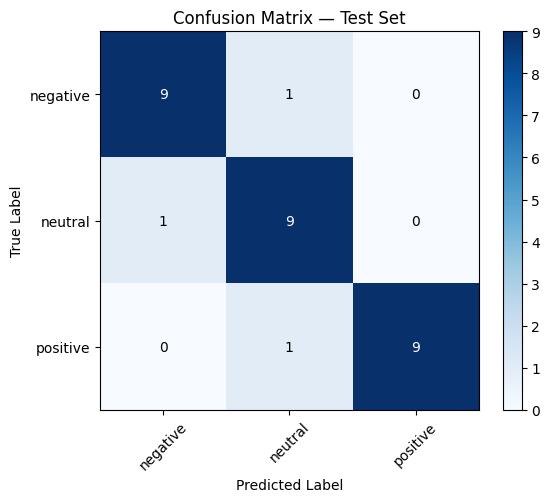

In [8]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix — Test Set')
plt.colorbar(im, ax=ax)

tick_marks = np.arange(NUM_LABELS)
ax.set_xticks(tick_marks)
ax.set_xticklabels(target_names, rotation=45)
ax.set_yticks(tick_marks)
ax.set_yticklabels(target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 5. Test Analysis & Report Visuals

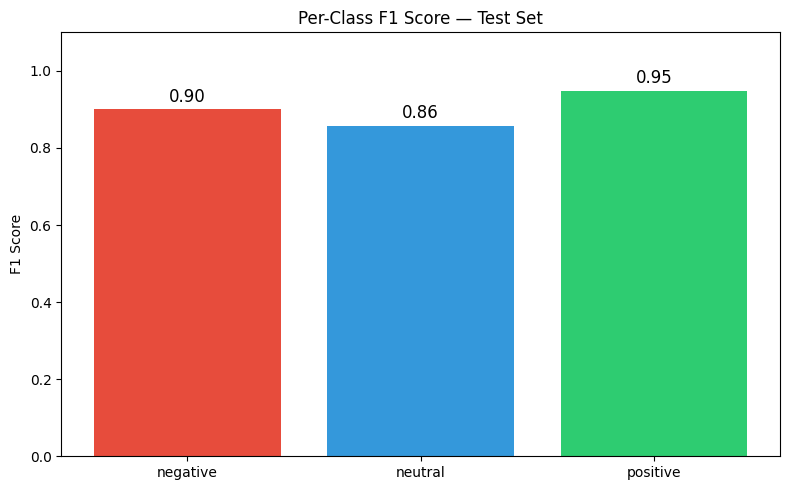

In [9]:
# Per-class F1 scores
test_f1_per = f1_score(test_labels, test_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(NUM_LABELS)
bars = ax.bar(x, test_f1_per, color=['#e74c3c', '#3498db', '#2ecc71'])

ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — Test Set')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.set_ylim(0, 1.1)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

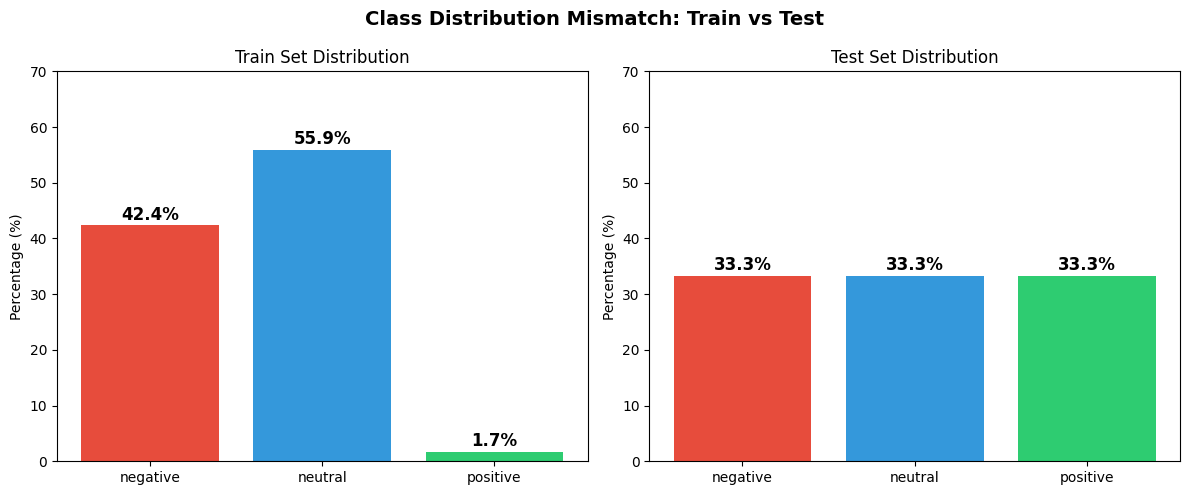

The test set is perfectly balanced (33.3% each), but the training set has
only 1.7% positive samples. The model essentially never learned to predict 'positive'.


In [10]:
# Distribution mismatch: the root cause of poor test performance
train_df = pd.read_csv('../dataset/processed/train_split.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train distribution
train_dist = train_df['label'].value_counts(normalize=True).sort_index() * 100
axes[0].bar(target_names, train_dist.values, color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Train Set Distribution')
axes[0].set_ylabel('Percentage (%)')
for i, v in enumerate(train_dist.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 70)

# Test distribution
test_dist = pd.Series(test_labels).value_counts(normalize=True).sort_index() * 100
axes[1].bar(target_names, test_dist.values, color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(test_dist.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 70)

plt.suptitle('Class Distribution Mismatch: Train vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("The test set is perfectly balanced (33.3% each), but the training set has")
print("only 1.7% positive samples. The model essentially never learned to predict 'positive'.")

In [11]:
# Summary results table
results_data = {
    'Metric': ['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'F1 negative', 'F1 neutral', 'F1 positive'],
    'Test': [
        f'{test_acc:.4f}',
        f'{test_f1_weighted:.4f}',
        f'{test_f1_macro:.4f}',
        f'{test_f1_per[0]:.4f}',
        f'{test_f1_per[1]:.4f}',
        f'{test_f1_per[2]:.4f}'
    ]
}
pd.DataFrame(results_data)

,Metric,Test
0,Accuracy,0.9000
1,F1 (weighted),0.9015
2,F1 (macro),0.9015
3,F1 negative,0.9000
4,F1 neutral,0.8571
5,F1 positive,0.9474


### Analysis

**Model:** DeBERTa-v3-base (optimized: 10 epochs, focal loss γ=2, batch size 4)

**Root Cause of Val→Test Gap: Distribution Mismatch**
- Training set: negative 42.4%, neutral 55.9%, positive 1.7%
- Test set: perfectly balanced at 33.3% each
- The model learned the training distribution, not the true decision boundary for the positive class

**Potential Improvements:**
- Data augmentation for the positive class (paraphrasing, back-translation)
- Few-shot learning approaches instead of standard fine-tuning
- Oversampling positive examples during training
- Using a smaller model (deberta-v3-small) to reduce overfitting risk with only 970 samples

## 6. Log Results to W&B

In [12]:
wandb.init(
    project='customer-sentiment-analysis',
    name='deberta-v3-base-test-eval',
    config={
        'model_dir': model_dir,
        'max_length': MAX_LENGTH,
        'test_size': len(test_df)
    }
)

wandb.log({
    'test/accuracy': test_acc,
    'test/f1_weighted': test_f1_weighted,
    'test/f1_macro': test_f1_macro,
    'test/loss': test_loss,
    'test/confusion_matrix': wandb.plot.confusion_matrix(
        y_true=test_labels.tolist(),
        preds=test_preds.tolist(),
        class_names=target_names
    )
})

wandb.finish()
print("Done. Results logged to wandb.")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/ofm/.netrc.
wandb: Currently logged in as: mereyomerfaruk (team-lingua) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test/accuracy,▁
test/f1_macro,▁
test/f1_weighted,▁
test/loss,▁
test/accuracy,0.9
test/f1_macro,0.9015
test/f1_weighted,0.9015
test/loss,0.38731


Done. Results logged to wandb.
